In [1]:
import numpy as np
import pandas as pd
import sys
sys.path.append('/Users/edatkinson/Repos/Modelling/new_approach')
from prepare_trainingdata import prepare_data
from train_classifier import train_classifier, train_and_evaluate, process_df, confidence_analysis, plot_metrics, train_classifier_calibrated,process_results, get_confidence, alphaFold, dna_shape,gcContent,dna_props,cons_features
import itertools
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import precision_recall_curve
from collections import Counter
import random
random.seed(100)

changes:
Added data to train_and_evaluate and train_classifier returns

In [2]:
inframe = '/Users/edatkinson/Repos/Modelling/data/pmed_log_inframe.csv'
frameshift = '/Users/edatkinson/Repos/Modelling/data/pmed_log_frameshift.csv'

features = [alphaFold, dna_shape,gcContent,dna_props,cons_features]
df = pd.read_csv(frameshift, sep=',')
df, dic = process_df(df, return_chroms=True)



In [3]:
dic

{'chr1': 4,
 'chr2': 17,
 'chr3': 7,
 'chr4': 3,
 'chr5': 10,
 'chr6': 19,
 'chr7': 1,
 'chr8': 22,
 'chr9': 8,
 'chr10': 11,
 'chr11': 16,
 'chr12': 20,
 'chr13': 2,
 'chr14': 18,
 'chr15': 9,
 'chr16': 14,
 'chr17': 12,
 'chr18': 13,
 'chr19': 6,
 'chr20': 21,
 'chr21': 15,
 'chr22': 5}

In [4]:
actual_predicted, feature_importance, final_model_tuple, results_tuple, data, chrom_performances = train_and_evaluate(df, features, pmed=False,verbose=True)

< ------------------------------------------------------------ > 

Test Classification Report: 
               precision    recall  f1-score   support

           0       0.64      0.91      0.75       178
           1       0.98      0.89      0.93       843

    accuracy                           0.90      1021
   macro avg       0.81      0.90      0.84      1021
weighted avg       0.92      0.90      0.90      1021
 

< ------------------------------------------------------------ > 

Cross Validation Classification Report: 
               precision    recall  f1-score   support

         0.0       0.66      0.89      0.76      1618
         1.0       0.97      0.88      0.92      6138

    accuracy                           0.88      7756
   macro avg       0.81      0.88      0.84      7756
weighted avg       0.90      0.88      0.89      7756
 

< ------------------------------------------------------------ > 



In [5]:

def remap_chroms(dic, chrom_performances):
    inv_dic = {v: k for k, v in dic.items()}
    test_case = inv_dic[1], inv_dic[2], inv_dic[3] # always first 3

    print('random test group =', test_case)

    # Remap chrom_performances keys
    remapped_chrom = {
        inv_dic.get(k, f'chr{k}') if k >3 else 'test': v for k, v in chrom_performances.items()
    }

    return remapped_chrom, test_case, inv_dic

remapped_chrom, test_case, inv_dic = remap_chroms(dic, chrom_performances)

random test group = ('chr7', 'chr13', 'chr4')


In [6]:
#Support for each chromosome
chroms = list(remapped_chrom.keys())
summ = 0 #8777
passenger = 0
driver = 0
for chr in chroms:
    c = Counter(remapped_chrom[chr]['actual'])
    total = c[1]+c[0]
    passenger += c[0]
    driver += c[1]
    print(chr, ":",c, "total:", total)
    summ+= total

print("drivers: ", driver, "passengers: ", passenger, "total", summ)
#Plot bar charts of the distribution of dataset


chr1 : Counter({1: 721, 0: 138}) total: 859
chr22 : Counter({1: 78, 0: 33}) total: 111
chr19 : Counter({0: 195, 1: 186}) total: 381
chr3 : Counter({1: 486, 0: 115}) total: 601
chr9 : Counter({1: 242, 0: 83}) total: 325
chr15 : Counter({1: 116, 0: 51}) total: 167
chr5 : Counter({1: 526, 0: 16}) total: 542
chr10 : Counter({1: 213, 0: 61}) total: 274
chr17 : Counter({1: 962, 0: 116}) total: 1078
chr18 : Counter({1: 88, 0: 34}) total: 122
chr16 : Counter({1: 323, 0: 60}) total: 383
chr21 : Counter({0: 37}) total: 37
chr11 : Counter({1: 400, 0: 148}) total: 548
chr2 : Counter({1: 641, 0: 136}) total: 777
chr14 : Counter({1: 159, 0: 49}) total: 208
chr6 : Counter({1: 258, 0: 133}) total: 391
chr12 : Counter({1: 445, 0: 104}) total: 549
chr20 : Counter({1: 56, 0: 42}) total: 98
chr8 : Counter({1: 238, 0: 67}) total: 305
test : Counter({1: 843, 0: 178}) total: 1021
drivers:  6981 passengers:  1796 total 8777


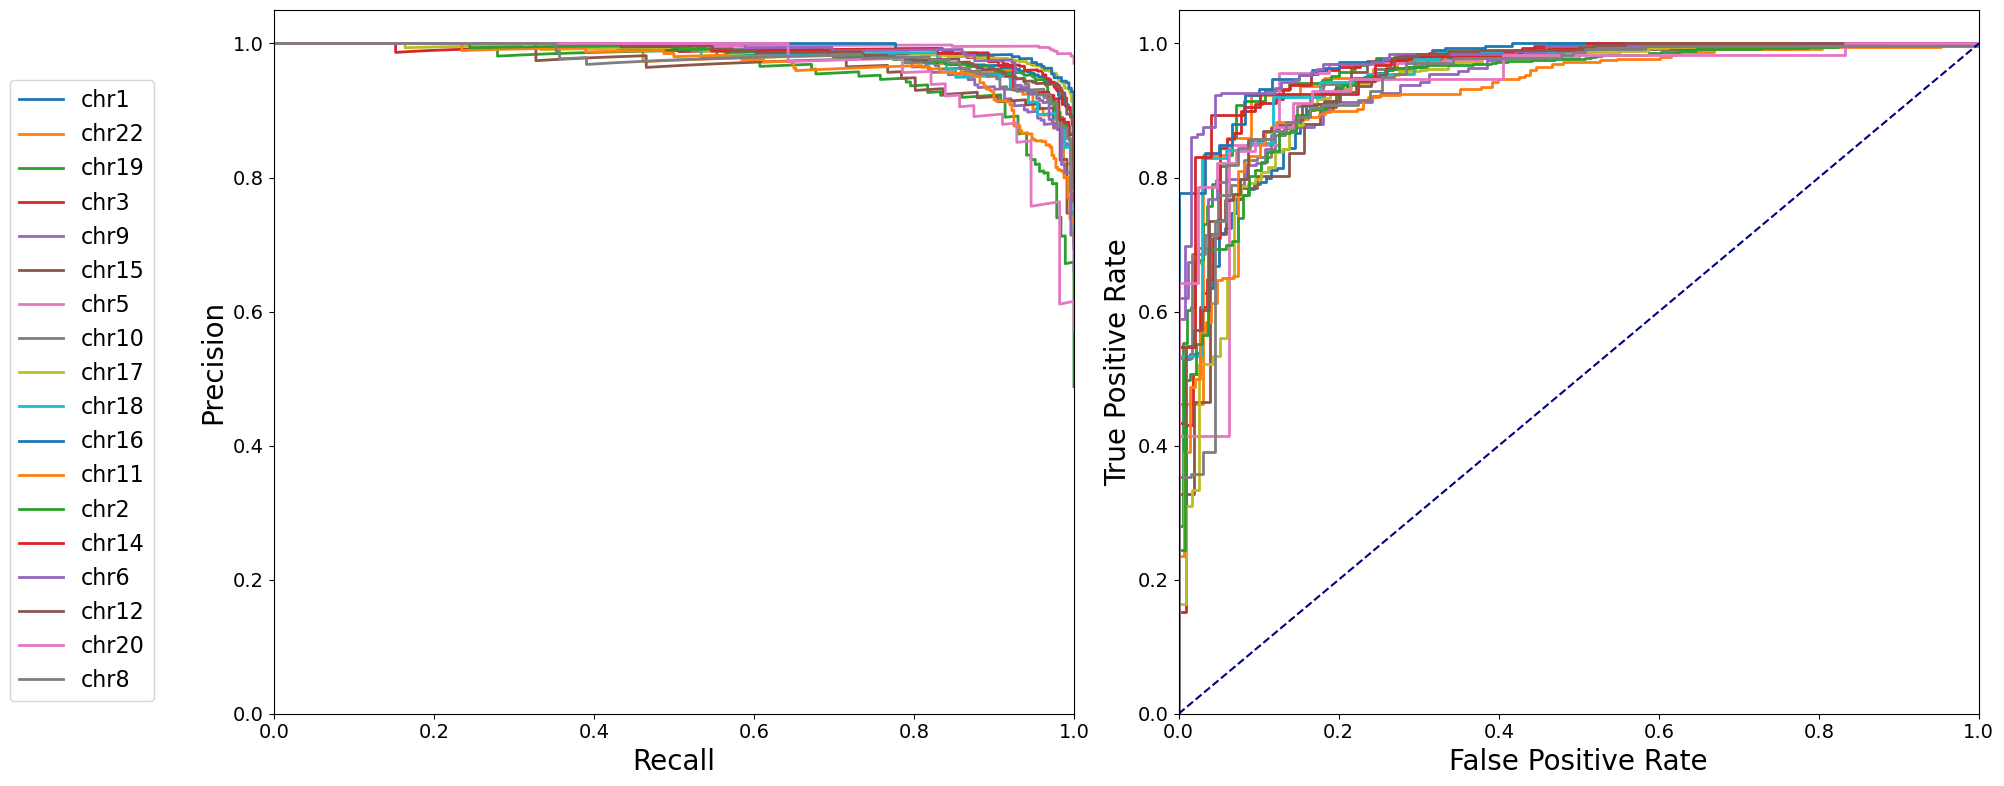

In [7]:
"""
Plots ROC and PR curves for individual chromosomes during cross validation

"""

def handle_probs(probs):
    # Ensure the input is a dictionary
    if not isinstance(probs, dict):
        raise TypeError("Expected input to be a dictionary where values are lists of tuples (confidence, index, actual_y, pred_y).")

    # Flatten the data into a list of (confidence, index, actual_y, pred_y) tuples
    flattened_data = []
    for sublist in probs.values():
        if isinstance(sublist, list):  # Ensure it's a list before iterating
            flattened_data.extend(sublist)
    
    # Sort by index
    sorted_data = sorted(flattened_data, key=lambda x: x[1])

    # Convert to a DataFrame
    df = pd.DataFrame(sorted_data, columns=["probability", "Index", "actual", "predicted"])
    df['confidence'] = get_confidence(df['probability'])[0]
    return df


fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for chrom, values in remapped_chrom.items():
    if 'conf' not in values:
        continue  # Skip if confidence info isn't available

    if chrom == 'test':
        continue
    if chrom == 'chr21':
        continue
    
    # Build dictionary in the required format for handle_probs
    prob_chrom = pd.Series([values['conf']], index=[chrom]).to_dict()
    
    # Get actual and predicted probabilities
    y = handle_probs(prob_chrom)
    ytruecv = y['actual']
    y_probacv = y['probability']
    
    # Plot PR Curve
    precision, recall, _ = precision_recall_curve(ytruecv, y_probacv)
    axes[0].plot(recall, precision, lw=2, label=f'{chrom}', alpha=1)
    
    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(ytruecv, y_probacv)
    auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, lw=2, label=f'ROC: {chrom} (AUC = {auc_val:.2f})', alpha=1)


# Final formatting
axes[0].set_xlabel('Recall', fontsize=20)
axes[0].set_ylabel('Precision', fontsize=20)

axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].tick_params(axis='both', which='major', labelsize=14)

axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[1].set_xlabel('False Positive Rate', fontsize=20)
axes[1].set_ylabel('True Positive Rate', fontsize=20)

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].tick_params(axis='both', which='major', labelsize=14)

axes[0].legend(bbox_to_anchor=(-0.15, 0.9), loc='upper right', fontsize=16, borderaxespad=0.)
# axes[1].legend(bbox_to_anchor=(1.05, 0.9), loc='upper left', fontsize=16, borderaxespad=0.)
plt.tight_layout()
plt.show()



Testing Chromosomes =  ('chr7', 'chr13', 'chr4') Comprising of Counter({1: 843, 0: 178})


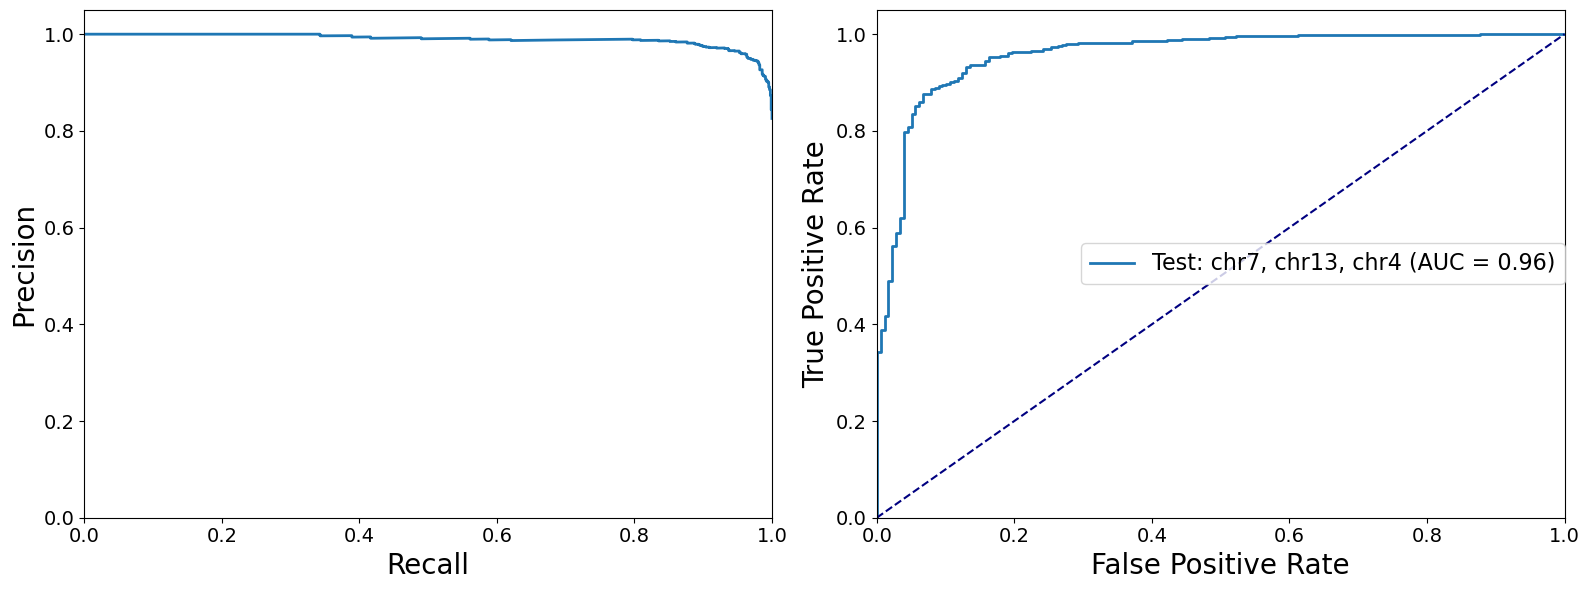

corner = 0.535,  J = 0.595,  cost = 0.030


In [9]:
"""
Plots PR and ROC curve for test case
"""

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Build dictionary in the required format for handle_probs
prob_chrom = pd.Series([remapped_chrom['test']['conf']]).to_dict()
print('Testing Chromosomes = ', test_case, "Comprising of", Counter(remapped_chrom['test']['actual']))


# Get actual and predicted probabilities
y = handle_probs(prob_chrom)
ytrue = y['actual']
y_proba = y['probability']

# Plot PR Curve
precision, recall, _ = precision_recall_curve(ytrue, y_proba)
axes[0].plot(recall, precision, lw=2, label=f'{chrom}', alpha=1)

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(ytrue, y_proba)
auc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, lw=2, label=f'Test: {test_case[0]}, {test_case[1]}, {test_case[2]} (AUC = {auc_val:.2f})', alpha=1)

# Write recall, precision, fpr and tpr to csv file
df_metrics = pd.DataFrame({'recall': recall, 'precision': precision})
df_metrics.to_csv('precision_recall_nopmed.csv', index=False)

df_roc = pd.DataFrame({'fpr': fpr, 'tpr': tpr})
df_roc.to_csv('fpr_tpr_nopmed.csv', index=False)

# Final formatting
axes[0].set_xlabel('Recall', fontsize=20)
axes[0].set_ylabel('Precision', fontsize=20)

axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].tick_params(axis='both', which='major', labelsize=14)

axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[1].set_xlabel('False Positive Rate', fontsize=20)
axes[1].set_ylabel('True Positive Rate', fontsize=20)

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].tick_params(axis='both', which='major', labelsize=14)

# axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, borderaxespad=0.)
axes[1].legend(loc='right', fontsize=16, borderaxespad=0.)
plt.tight_layout()
plt.show()

import numpy as np

# ► 3a  closest-corner
dist = np.sqrt(fpr**2 + (1 - tpr)**2)
t_corner = thresholds[np.argmin(dist)]

# ► 3b  Youden-J
youden = tpr - fpr
t_j     = thresholds[np.argmax(youden)]

# ► 3c  cost-based (set ρ first)
rho = 10                     # e.g. FN is 10× worse than FP
fnr = 1 - tpr
cost = rho*fnr + fpr
t_cost = thresholds[np.argmin(cost)]

print(f"corner = {t_corner:.3f},  J = {t_j:.3f},  cost = {t_cost:.3f}")





0.9894545855015192


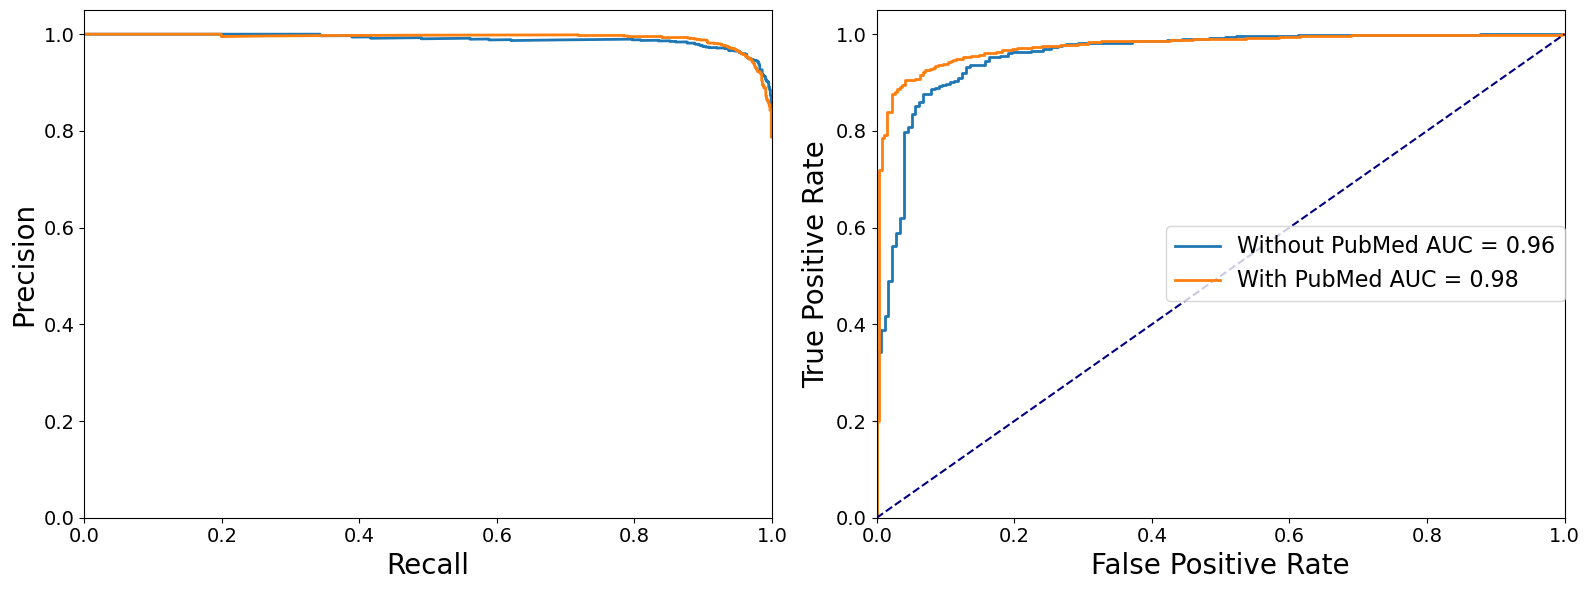

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

nopmed_roc, nopmed_prec = pd.read_csv('/Users/edatkinson/Repos/Modelling/testing/fpr_tpr_nopmed.csv'), pd.read_csv('/Users/edatkinson/Repos/Modelling/testing/precision_recall_nopmed.csv')
pmed_roc, pmed_prec = pd.read_csv('/Users/edatkinson/Repos/Modelling/testing/fpr_tpr_pmed.csv'), pd.read_csv('/Users/edatkinson/Repos/Modelling/testing/precision_recall_pmed.csv')

recall, precision = nopmed_prec['recall'], nopmed_prec['precision']
recall_p, precision_p = pmed_prec['recall'], pmed_prec['precision']

tpr, fpr = nopmed_roc['tpr'], nopmed_roc['fpr']
tpr_p, fpr_p = pmed_roc['tpr'], pmed_roc['fpr']
auc_val = auc(fpr, tpr)
auc_val_p = auc(fpr_p, tpr_p)

pr_auc = auc(recall, precision)
print(pr_auc)
# Plot ROC curve
axes[1].plot(fpr, tpr, lw=2, label=f'Without PubMed AUC = {auc_val:.2f}', alpha=1)
axes[1].plot(fpr_p, tpr_p, lw=2, label=f'With PubMed AUC = {auc_val_p:.2f}', alpha=1)
# Plot PR Curve

axes[0].plot(recall, precision, lw=2, label=f'{chrom} : No PubMed')
axes[0].plot(recall_p, precision_p, lw=2, label=f'{chrom}: PubMed')

# Final formatting
axes[0].set_xlabel('Recall', fontsize=20)
axes[0].set_ylabel('Precision', fontsize=20)

axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].tick_params(axis='both', which='major', labelsize=14)

axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[1].set_xlabel('False Positive Rate', fontsize=20)
axes[1].set_ylabel('True Positive Rate', fontsize=20)

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].tick_params(axis='both', which='major', labelsize=14)

# axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, borderaxespad=0.)
axes[1].legend(loc='right', fontsize=16, borderaxespad=0.)
plt.tight_layout()
plt.show() # 7, 13, 4

/var/folders/1d/6gng4gzs5v7fgpk588n4m3yw0000gn/T/ipykernel_72735/542733353.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(chromosomes, rotation=45, ha='right', fontsize=14)


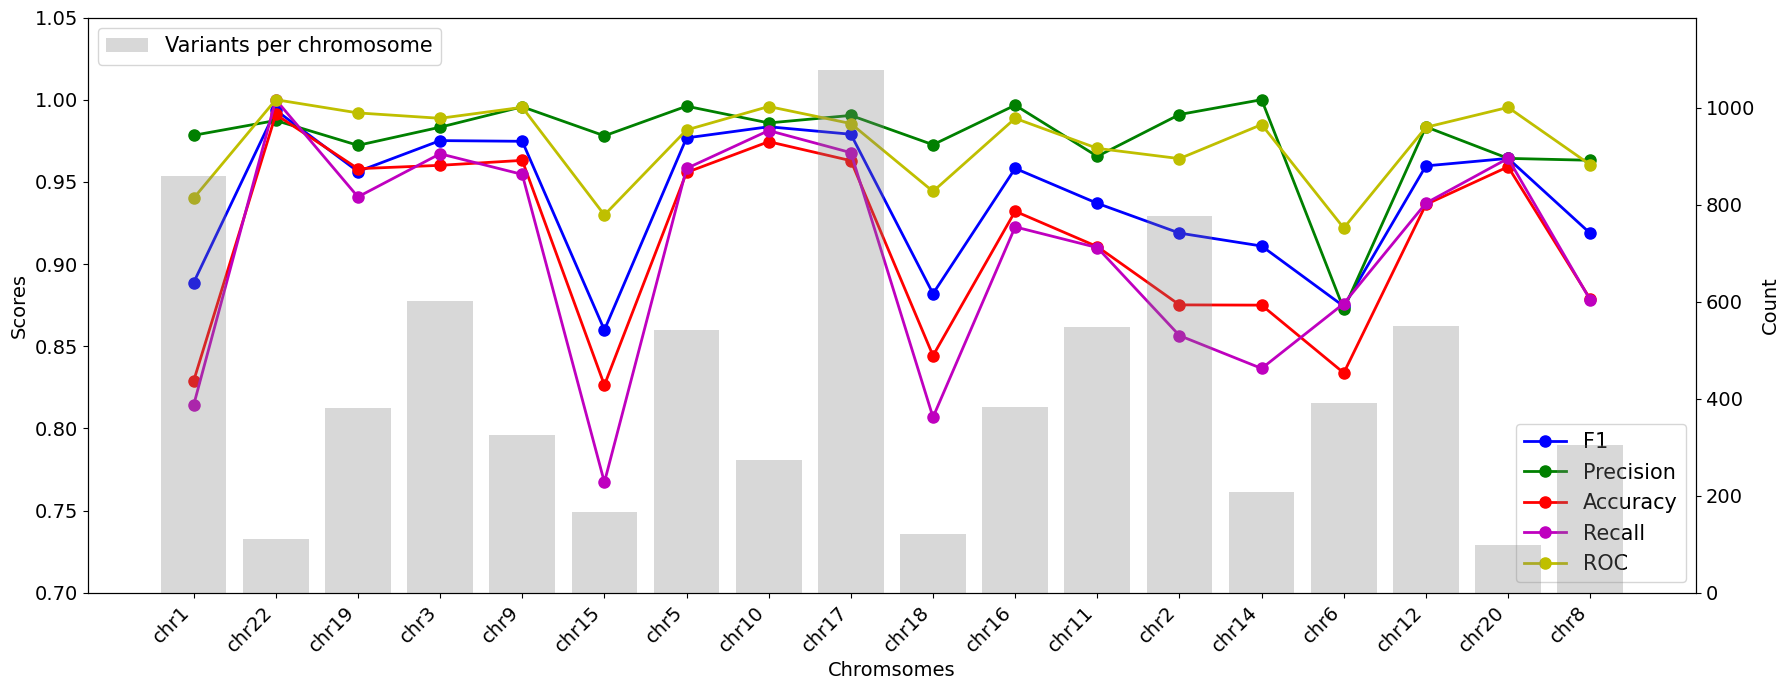

In [ ]:


# Extract F1 scores for each chromosome
f1_scores = {chrom: remapped_chrom[chrom]['f1'] for chrom in remapped_chrom if 'f1' in remapped_chrom[chrom] and chrom != 'test' and chrom != 'chr21'}
p_scores = {chrom: remapped_chrom[chrom]['precision'] for chrom in remapped_chrom if 'precision' in remapped_chrom[chrom] and chrom != 'test' and chrom != 'chr21'}
a_scores = {chrom: remapped_chrom[chrom]['accuracy'] for chrom in remapped_chrom if 'accuracy' in remapped_chrom[chrom] and chrom != 'test' and chrom != 'chr21'}
roc_scores = {chrom: remapped_chrom[chrom]['roc_auc'] for chrom in remapped_chrom if 'roc_auc' in remapped_chrom[chrom] and chrom != 'test' and chrom != 'chr21'}
recall_scores = {chrom: remapped_chrom[chrom]['recall'] for chrom in remapped_chrom if 'recall' in remapped_chrom[chrom] and chrom != 'test' and chrom != 'chr21'}


counts = {chrom: remapped_chrom[chrom]['count'] for chrom in remapped_chrom if 'count' in remapped_chrom[chrom] and chrom != 'test' and chrom != 'chr21'}

# Prepare data for plotting
chromosomes = list(f1_scores.keys())
scores = list(f1_scores.values())

# Plot
fig, ax = plt.subplots(figsize=(18, 7))

ax.plot(chromosomes, scores, marker='o', color='blue', linestyle='-', linewidth=2, markersize=8, label='F1')
ax.plot(chromosomes, list(p_scores.values()), marker='o', color='g', linestyle='-', linewidth=2, markersize=8, label='Precision')
ax.plot(chromosomes, list(a_scores.values()), marker='o', color='r', linestyle='-', linewidth=2, markersize=8, label='Accuracy')
ax.plot(chromosomes, list(recall_scores.values()), marker='o', color='m', linestyle='-', linewidth=2, markersize=8, label='Recall')
ax.plot(chromosomes, list(roc_scores.values()), marker='o', color='y', linestyle='-', linewidth=2, markersize=8, label='ROC')

ax.set_ylabel('Scores', fontsize=14)
ax.set_ylim([0.7, 1.05])
ax.set_xticklabels(chromosomes, rotation=45, ha='right', fontsize=14)
ax.set_xlabel('Chromsomes', fontsize=14)

# Set the x-tick label size to be bigger
ax.tick_params(axis='y', which='major', labelsize=14)  # You can change '16' to your desired size

ax2 = ax.twinx()
ax2.tick_params(axis='y', which='major', labelsize=14)  # You can change '16' to your desired size

# Plot the bar chart for counts
ax2.bar(chromosomes, list(counts.values()), color='gray', alpha=0.3, label='Variants per chromosome')

ax2.set_ylabel('Count', fontsize=14)
ax2.set_ylim([0, max(counts.values()) * 1.1])  # Make sure the bars fit nicely in the plot

ax.legend(loc='lower right', fontsize=15)
ax2.legend(loc='upper left', fontsize=15)
# Tight layout for proper space allocation
plt.tight_layout()
plt.show()




driver_stat
1    1999
0     145
Name: count, dtype: int64
predicted
1    1977
0     167
Name: count, dtype: int64


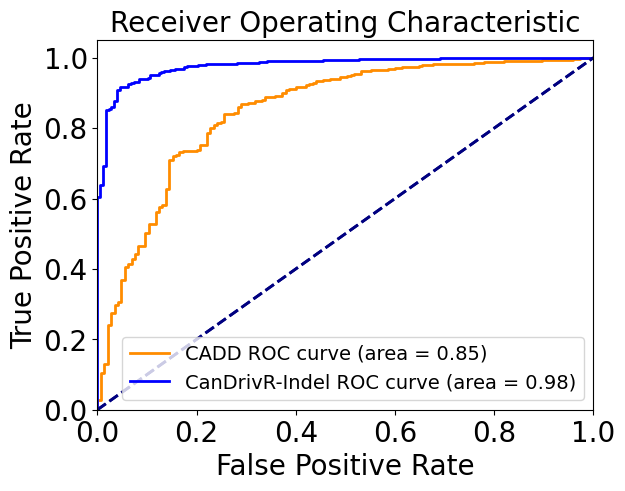

              precision    recall  f1-score   support

           0       0.42      0.48      0.45       145
           1       0.96      0.95      0.96      1999

    accuracy                           0.92      2144
   macro avg       0.69      0.72      0.70      2144
weighted avg       0.93      0.92      0.92      2144



In [ ]:
def plot_precision_recall_roc(y_true, y_proba, fig, ax, label="", color='blue'):
    """
    Plots the precision-recall curve and ROC curve for a given set of true labels and predicted probabilities.

    Parameters:
    - y_true: True labels (binary).
    - y_proba: Predicted probabilities for the positive class.
    - title_prefix: Optional prefix for the plot titles.
    """
    

    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, lw=2, label=f'{label} ROC curve (area = {roc_auc:.2f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.set_xlabel('False Positive Rate', fontsize=20)
    ax.set_ylabel('True Positive Rate',fontsize=20)
    ax.set_title('Receiver Operating Characteristic',fontsize=20)
    ax.legend(loc="lower right", fontsize=14)
    
    return fig, ax



def process_CADD_annotations(file):
    mydf = pd.read_csv('/Users/edatkinson/Repos/Modelling/data/pmed_log_frameshift.csv', sep=',')

    df = pd.read_csv(file, sep='\t', skiprows=1)
    df.rename(columns={'#Chrom':'chrom', 'Pos':'pos', 'Ref':'ref_allele', 'Alt':'alt_allele'}, inplace=True)
    df['chrom'] = df['chrom'].apply(lambda x: 'chr'+str(x))

    # Define a function to classify based on PHRED score
    def classify_variant(phred):
        if phred < 15:
            return 0
        else:
            return 1

    # Apply classification
    df['predicted'] = df['PHRED'].apply(classify_variant)


    # df['actual'] is the merged 
    merged = pd.merge(mydf, df, on=['chrom', 'pos', 'ref_allele', 'alt_allele'], how='right')

    print(merged['driver_stat'].value_counts())
    print(merged['predicted'].value_counts())

    # print(classification_report(merged['driver_stat'], merged['PHRED']))
    return merged

"""
Need to retrain model on the outset of this cadd data, then test it on the cadd set so I can have a fair comparison, at the moment it compares my accuracy on a different test set with CADD's accuracy on it's dataset

"""


merged = process_CADD_annotations('/Users/edatkinson/Repos/Modelling/testing/cadd_frameshift.tsv')

fig, ax = plt.subplots()
fig, ax = plot_precision_recall_roc(merged['driver_stat'], merged['RawScore'], fig, ax, color='darkorange', label='CADD')
# roc_curve(ytrue, y_proba)[1]
fig2, ax2 = plot_precision_recall_roc(ytrue, y_proba, fig, ax, color='blue', label='CanDrivR-Indel')

plt.show()
print(classification_report(merged['driver_stat'], merged['predicted']))



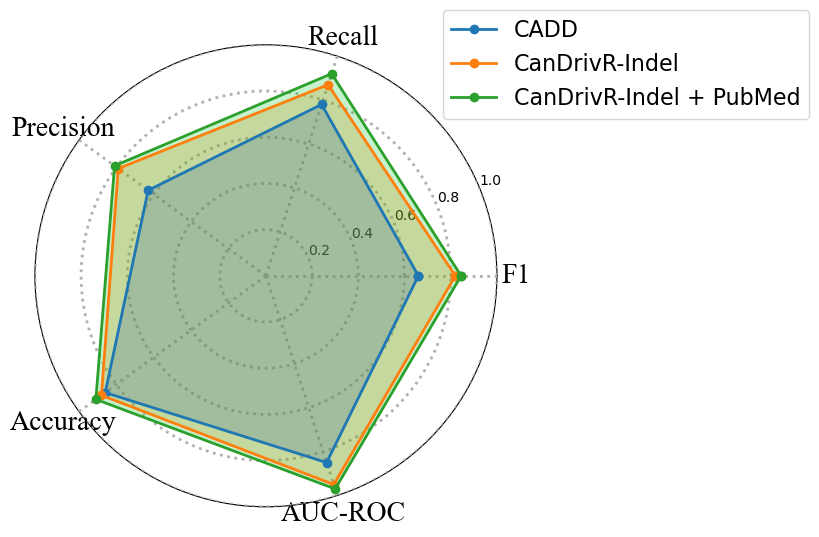

In [ ]:


# sns.set_theme(style="whitegrid")  # You can also use "darkgrid", "white", etc.

# Choose a color palette (e.g., "Set2", "muted", "deep", etc.)
palette = sns.color_palette("bright", n_colors=3)

# Metrics to display on the spider chart
metrics = ["F1", "Recall", "Precision", "Accuracy", "AUC-ROC"]
N = len(metrics)
# CADD scores
cadd_scores = [0.66, 0.78, 0.63, 0.86, 0.85]

# CanDrivR-Indel scores (without pmed)
candrivr_scores = [0.82, 0.87, 0.79, 0.88, 0.95]

candrivr_scores_pmed = [0.845, 0.92,0.81, 0.91, 0.97 ]

# We need to "close the loop": append the first score to the end
cadd_scores += [cadd_scores[0]]
candrivr_scores += [candrivr_scores[0]]
candrivr_scores_pmed += [candrivr_scores_pmed[0]]

# Angles equally spaced around a circle
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += [angles[0]]  # close the circle

# Create polar subplot
fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(6, 6))

# Draw one axis per metric + the associated labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontdict={'fontsize': 20, 'fontname': 'Times New Roman'})

ax.grid(linestyle=':', linewidth=2)
ax.set_axisbelow(True)

# Set radial limits (0 to 1 in this case)
ax.set_ylim(0, 1)

# Plot data for CADD
ax.plot(angles, cadd_scores, linewidth=2, label="CADD", marker='o')
ax.fill(angles, cadd_scores, alpha=0.25, color=palette[0])

# Plot data for CanDrivR-Indel
ax.plot(angles, candrivr_scores, linewidth=2, label="CanDrivR-Indel", marker='o')
ax.fill(angles, candrivr_scores, alpha=0.25, color=palette[1])

ax.plot(angles, candrivr_scores_pmed, linewidth=2, label="CanDrivR-Indel + PubMed", marker='o')
ax.fill(angles, candrivr_scores_pmed, alpha=0.25, color=palette[2])
for spine in ax.spines.values():
    spine.set_zorder(0)

plt.legend(loc="upper right", bbox_to_anchor=(1.7, 1.1), fontsize=16)
plt.show()

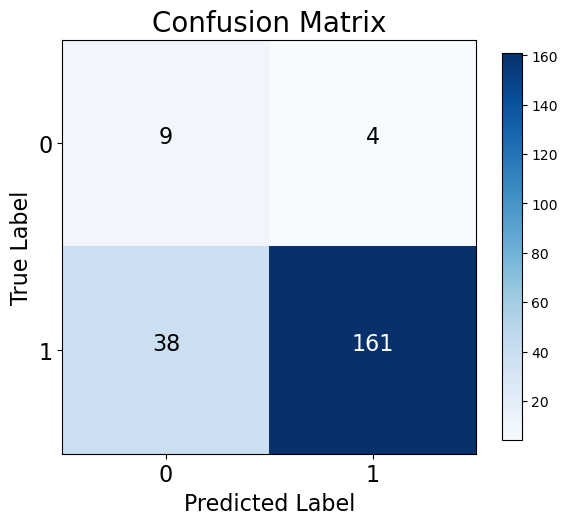

In [ ]:
#Confusion Matrix:

probabilities_test = results_tuple[1]['pos_conf'].to_dict()
probs_test = handle_probs(probabilities_test)

def confusion_matrix_maker(confidence_df, threshold=0.9):

    # Apply new threshold to generate adjusted predictions
    confidence_df["adjusted_prediction"] = (confidence_df["probability"] >= threshold).astype(int)

    # Compute classification metrics
    report = classification_report(confidence_df["actual"], confidence_df["adjusted_prediction"], output_dict=True)
    conf_matrix = confusion_matrix(confidence_df["actual"], confidence_df["adjusted_prediction"])

    # Convert classification report to DataFrame for better visualization
    report_df = pd.DataFrame(confidence_df)


    return conf_matrix, report_df


cmat, res = confusion_matrix_maker(probs_test, threshold=0.50)






def plot_confmat(cmat):

    plt.figure(figsize=(6, 6))
    plt.imshow(cmat, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion Matrix", fontsize=20)
    plt.colorbar(shrink=0.7)
    #  Define tick marks based on the number of classes (assumed here to be 2)
    tick_marks = np.arange(cmat.shape[0])
    plt.xticks(tick_marks, tick_marks, fontsize=16)
    plt.yticks(tick_marks, tick_marks, fontsize=16)

    # Loop over data dimensions and create text annotations.
    thresh = cmat.max() / 2.0
    for i in range(cmat.shape[0]):
        for j in range(cmat.shape[1]):
            plt.text(j, i, format(cmat[i, j], 'd'),
                    horizontalalignment="center",
                    color="white" if cmat[i, j] > thresh else "black", fontsize=16)

    plt.ylabel("True Label", fontsize = 16)
    plt.xlabel("Predicted Label", fontsize = 16)
    plt.tight_layout()
    plt.show()

plot_confmat(cmat)

In [ ]:
#482